# Amazon Review Data Analysis

In [143]:
# packages for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [144]:
# import csv file
sentiment_reviews = pd.read_csv('SCI_Predictions_topP_0.65.csv')
sentiment_reviews.head()

,Unnamed: 0,Index,Review_link,Rating,Review_title,Review_body,Country,Date,Number_helpful,security_related,...,has_password,has_update,has_privacy,has_encrypt,any_security_flag,pred_neg,pred_neu,pred_pos,pred_label_id,pred_label
0,3,id_5,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,5,Great Quality Camera,We purchased two Wyze Cams to monitor our home...,Australia,2020-03-22,NaN,True,...,False,False,False,False,True,0.004585,0.058173,0.937242,2,positive
1,4,id_5,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,5,Amazing value for money!,"If, like me, you want the best possible securi...",Australia,2020-10-06,NaN,True,...,False,False,False,False,True,0.008763,0.030529,0.960708,2,positive
2,6,id_5,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,5,All that you need for a security camera.,Superb camera for the price. Have 4 of these i...,Australia,2021-03-28,NaN,True,...,False,False,False,False,True,0.006748,0.021595,0.971658,2,positive
3,7,id_5,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,5,Super easy to setup and use,I bought one first and now have 6 of them at d...,Australia,2021-01-04,NaN,True,...,False,False,False,False,True,0.007983,0.029873,0.962144,2,positive
4,10,id_5,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,5,Best for the bucks,All of the Premium features on such cheap cam....,Australia,2020-01-06,3,True,...,False,False,False,False,True,0.006382,0.053220,0.940399,2,positive


In [145]:
# import the other csv file
product_data = pd.read_csv('amazon_data/Amazon_IoT_product_data.csv', encoding='latin1')
product_data.head()

,Column1,Index,WebCountry,Link,Device Type,Product Title,Price,Currency,Description,Average Rating,Total Reviews,Percent 5 star,Percent 4 star,Percent 3 star,Percent 2 star,Percent 1 star
0,0,id_1,Australia,http://amazon.com.au/Xiaomi-Security-Surveilla...,Surveillance systems,Xiaomi Mi 360¡ Home Security Camera 2K Pro WLA...,101.74,101.74,[High resolution 2K resolution provides more n...,1.0,1.0,NaN,NaN,NaN,NaN,1.00
1,1,id_2,Australia,http://amazon.com.au/HIKVISION-Megapixel-Outdo...,Surveillance systems,HIKVISION 4 Megapixel EXIR PoE Turret IP Outdo...,193.43,193.43,"[4 megapixel high resolution (2688 x 1520) , F...",1.0,2.0,NaN,NaN,NaN,NaN,1.00
2,2,id_3,Australia,http://amazon.com.au/WEMLB-Detection-Recording...,Surveillance systems,WEMLB WB-726 HD 1080 P WiFi Hidden Camera Alar...,110.86,110.86,[Your FamilyÕs Safety First: Wondering if your...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,id_4,Australia,http://amazon.com.au/Wireless-Waterproof-Secur...,Surveillance systems,WiFi PTZ HD 5MP Wireless Waterproof Security S...,196.65,196.65,[_HD Image and UP to 115FT Night Vision_:This ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,id_5,Australia,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,Surveillance systems,Wyze Cam 1080p HD Indoor Wireless Smart Home C...,72.83,72.83,[Works with Alexa: ask Alexa to show your fron...,4.4,176.0,0.7,0.14,0.07,0.05,0.04


In [146]:
# input another csv file
review_data = pd.read_csv('amazon_data/Amazon_IoT_product_reviews.csv', encoding='latin1')
review_data.head()

,Unnamed: 0,Index,Review_link,Rating,Review_title,Review_body,Country,Date,Number_helpful
0,0,id_1,http://amazon.com.au/Xiaomi-Security-Surveilla...,1,Spamming,"After registering my email on xiaomi, i have s...",Australia,23 April 2021,NaN
1,1,id_5,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,5,Worth it for sure...,Bought these for cameras around my truck for r...,Australia,27 September 2020,NaN
2,2,id_5,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,5,Wyze cameras bang for buck are the best value ...,These cameras are fantastic. Amazon need to st...,Australia,31 October 2020,NaN
3,3,id_5,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,5,Great Quality Camera,We purchased two Wyze Cams to monitor our home...,Australia,22 March 2020,NaN
4,4,id_5,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,5,Amazing value for money!,"If, like me, you want the best possible securi...",Australia,6 October 2020,NaN


## Calculating the SCI

In [147]:
# SCI defined as the ratio of the number of security-related reviews to the total number of reviews per product
# two options defining security-related reviews: 
# with "any_security_flag" = TRUE or both "any_security_flag" = TRUE and pred_label = "negative"
# first we will do the first option by adding the number of reviews with "any_security_flag" = TRUE per product in the product_data
# count the number of reviews with "any_security_flag" = TRUE per product
security_reviews_count = sentiment_reviews[sentiment_reviews['any_security_flag'] == True].groupby('Index').size().reset_index(name='security_reviews_count')
# count the total number of reviews per product
total_reviews_count = review_data.groupby('Index').size().reset_index(name='total_reviews_count')
# merge the two dataframes
reviews_count = pd.merge(total_reviews_count, security_reviews_count, on='Index', how='left')
reviews_count.head()

,Index,total_reviews_count,security_reviews_count
0,id_1,1,NaN
1,id_10,45,13.0
2,id_1000,39,17.0
3,id_1001,128,52.0
4,id_1002,132,32.0


In [148]:
# now add the sentiment consideration into reviews_count
sentiment_security_reviews_count = sentiment_reviews[(sentiment_reviews['any_security_flag'] == True) & (sentiment_reviews['pred_label'] == 'negative')].groupby('Index').size().reset_index(name='sentiment_security_reviews_count')
reviews_count = pd.merge(reviews_count, sentiment_security_reviews_count, on='Index', how='left')
reviews_count.head()

,Index,total_reviews_count,security_reviews_count,sentiment_security_reviews_count
0,id_1,1,NaN,NaN
1,id_10,45,13.0,NaN
2,id_1000,39,17.0,1.0
3,id_1001,128,52.0,13.0
4,id_1002,132,32.0,8.0


In [149]:
# replace NaN values with 0
reviews_count['security_reviews_count'] = reviews_count['security_reviews_count'].fillna(0)
reviews_count['sentiment_security_reviews_count'] = reviews_count['sentiment_security_reviews_count'].fillna(0)
reviews_count.head()

,Index,total_reviews_count,security_reviews_count,sentiment_security_reviews_count
0,id_1,1,0.0,0.0
1,id_10,45,13.0,0.0
2,id_1000,39,17.0,1.0
3,id_1001,128,52.0,13.0
4,id_1002,132,32.0,8.0


In [150]:
# conver the counts to integers
reviews_count['sentiment_security_reviews_count'] = reviews_count['sentiment_security_reviews_count'].astype(int)
reviews_count.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Index                             1071 non-null   object 
 1   total_reviews_count               1071 non-null   int64  
 2   security_reviews_count            1071 non-null   float64
 3   sentiment_security_reviews_count  1071 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 33.6+ KB


In [151]:
# merge the reviews_count dataframe with the product_data dataframe
product_data = pd.merge(product_data, reviews_count, left_on='Index', right_on='Index', how='left')
product_data.head()

,Column1,Index,WebCountry,Link,Device Type,Product Title,Price,Currency,Description,Average Rating,Total Reviews,Percent 5 star,Percent 4 star,Percent 3 star,Percent 2 star,Percent 1 star,total_reviews_count,security_reviews_count,sentiment_security_reviews_count
0,0,id_1,Australia,http://amazon.com.au/Xiaomi-Security-Surveilla...,Surveillance systems,Xiaomi Mi 360¡ Home Security Camera 2K Pro WLA...,101.74,101.74,[High resolution 2K resolution provides more n...,1.0,1.0,NaN,NaN,NaN,NaN,1.00,1.0,0.0,0.0
1,1,id_2,Australia,http://amazon.com.au/HIKVISION-Megapixel-Outdo...,Surveillance systems,HIKVISION 4 Megapixel EXIR PoE Turret IP Outdo...,193.43,193.43,"[4 megapixel high resolution (2688 x 1520) , F...",1.0,2.0,NaN,NaN,NaN,NaN,1.00,1.0,0.0,0.0
2,2,id_3,Australia,http://amazon.com.au/WEMLB-Detection-Recording...,Surveillance systems,WEMLB WB-726 HD 1080 P WiFi Hidden Camera Alar...,110.86,110.86,[Your FamilyÕs Safety First: Wondering if your...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,id_4,Australia,http://amazon.com.au/Wireless-Waterproof-Secur...,Surveillance systems,WiFi PTZ HD 5MP Wireless Waterproof Security S...,196.65,196.65,[_HD Image and UP to 115FT Night Vision_:This ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,id_5,Australia,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,Surveillance systems,Wyze Cam 1080p HD Indoor Wireless Smart Home C...,72.83,72.83,[Works with Alexa: ask Alexa to show your fron...,4.4,176.0,0.7,0.14,0.07,0.05,0.04,96.0,36.0,5.0


In [152]:
# fill NaN values with 0
product_data['total_reviews_count'] = product_data['total_reviews_count'].fillna(0)
product_data['security_reviews_count'] = product_data['security_reviews_count'].fillna(0)
product_data['sentiment_security_reviews_count'] = product_data['sentiment_security_reviews_count'].fillna(0)
product_data.head()

,Column1,Index,WebCountry,Link,Device Type,Product Title,Price,Currency,Description,Average Rating,Total Reviews,Percent 5 star,Percent 4 star,Percent 3 star,Percent 2 star,Percent 1 star,total_reviews_count,security_reviews_count,sentiment_security_reviews_count
0,0,id_1,Australia,http://amazon.com.au/Xiaomi-Security-Surveilla...,Surveillance systems,Xiaomi Mi 360¡ Home Security Camera 2K Pro WLA...,101.74,101.74,[High resolution 2K resolution provides more n...,1.0,1.0,NaN,NaN,NaN,NaN,1.00,1.0,0.0,0.0
1,1,id_2,Australia,http://amazon.com.au/HIKVISION-Megapixel-Outdo...,Surveillance systems,HIKVISION 4 Megapixel EXIR PoE Turret IP Outdo...,193.43,193.43,"[4 megapixel high resolution (2688 x 1520) , F...",1.0,2.0,NaN,NaN,NaN,NaN,1.00,1.0,0.0,0.0
2,2,id_3,Australia,http://amazon.com.au/WEMLB-Detection-Recording...,Surveillance systems,WEMLB WB-726 HD 1080 P WiFi Hidden Camera Alar...,110.86,110.86,[Your FamilyÕs Safety First: Wondering if your...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
3,3,id_4,Australia,http://amazon.com.au/Wireless-Waterproof-Secur...,Surveillance systems,WiFi PTZ HD 5MP Wireless Waterproof Security S...,196.65,196.65,[_HD Image and UP to 115FT Night Vision_:This ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
4,4,id_5,Australia,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,Surveillance systems,Wyze Cam 1080p HD Indoor Wireless Smart Home C...,72.83,72.83,[Works with Alexa: ask Alexa to show your fron...,4.4,176.0,0.7,0.14,0.07,0.05,0.04,96.0,36.0,5.0


In [153]:
# calculate SCI based on the first option
product_data['SCI'] = product_data['security_reviews_count'] / product_data['total_reviews_count']
# replace NaN values with 0
product_data['SCI'] = product_data['SCI'].fillna(0)
product_data.head()

,Column1,Index,WebCountry,Link,Device Type,Product Title,Price,Currency,Description,Average Rating,Total Reviews,Percent 5 star,Percent 4 star,Percent 3 star,Percent 2 star,Percent 1 star,total_reviews_count,security_reviews_count,sentiment_security_reviews_count,SCI
0,0,id_1,Australia,http://amazon.com.au/Xiaomi-Security-Surveilla...,Surveillance systems,Xiaomi Mi 360¡ Home Security Camera 2K Pro WLA...,101.74,101.74,[High resolution 2K resolution provides more n...,1.0,1.0,NaN,NaN,NaN,NaN,1.00,1.0,0.0,0.0,0.000
1,1,id_2,Australia,http://amazon.com.au/HIKVISION-Megapixel-Outdo...,Surveillance systems,HIKVISION 4 Megapixel EXIR PoE Turret IP Outdo...,193.43,193.43,"[4 megapixel high resolution (2688 x 1520) , F...",1.0,2.0,NaN,NaN,NaN,NaN,1.00,1.0,0.0,0.0,0.000
2,2,id_3,Australia,http://amazon.com.au/WEMLB-Detection-Recording...,Surveillance systems,WEMLB WB-726 HD 1080 P WiFi Hidden Camera Alar...,110.86,110.86,[Your FamilyÕs Safety First: Wondering if your...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000
3,3,id_4,Australia,http://amazon.com.au/Wireless-Waterproof-Secur...,Surveillance systems,WiFi PTZ HD 5MP Wireless Waterproof Security S...,196.65,196.65,[_HD Image and UP to 115FT Night Vision_:This ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000
4,4,id_5,Australia,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,Surveillance systems,Wyze Cam 1080p HD Indoor Wireless Smart Home C...,72.83,72.83,[Works with Alexa: ask Alexa to show your fron...,4.4,176.0,0.7,0.14,0.07,0.05,0.04,96.0,36.0,5.0,0.375


In [154]:
# calculate SCI based on the second option
product_data['SCI_sentiment'] = product_data['sentiment_security_reviews_count'] / product_data['total_reviews_count']
# replace NaN values with 0
product_data['SCI_sentiment'] = product_data['SCI_sentiment'].fillna(0)
product_data.head()

,Column1,Index,WebCountry,Link,Device Type,Product Title,Price,Currency,Description,Average Rating,...,Percent 5 star,Percent 4 star,Percent 3 star,Percent 2 star,Percent 1 star,total_reviews_count,security_reviews_count,sentiment_security_reviews_count,SCI,SCI_sentiment
0,0,id_1,Australia,http://amazon.com.au/Xiaomi-Security-Surveilla...,Surveillance systems,Xiaomi Mi 360¡ Home Security Camera 2K Pro WLA...,101.74,101.74,[High resolution 2K resolution provides more n...,1.0,...,NaN,NaN,NaN,NaN,1.00,1.0,0.0,0.0,0.000,0.000000
1,1,id_2,Australia,http://amazon.com.au/HIKVISION-Megapixel-Outdo...,Surveillance systems,HIKVISION 4 Megapixel EXIR PoE Turret IP Outdo...,193.43,193.43,"[4 megapixel high resolution (2688 x 1520) , F...",1.0,...,NaN,NaN,NaN,NaN,1.00,1.0,0.0,0.0,0.000,0.000000
2,2,id_3,Australia,http://amazon.com.au/WEMLB-Detection-Recording...,Surveillance systems,WEMLB WB-726 HD 1080 P WiFi Hidden Camera Alar...,110.86,110.86,[Your FamilyÕs Safety First: Wondering if your...,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000,0.000000
3,3,id_4,Australia,http://amazon.com.au/Wireless-Waterproof-Secur...,Surveillance systems,WiFi PTZ HD 5MP Wireless Waterproof Security S...,196.65,196.65,[_HD Image and UP to 115FT Night Vision_:This ...,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000,0.000000
4,4,id_5,Australia,http://amazon.com.au/Wyze-Indoor-Wireless-Came...,Surveillance systems,Wyze Cam 1080p HD Indoor Wireless Smart Home C...,72.83,72.83,[Works with Alexa: ask Alexa to show your fron...,4.4,...,0.7,0.14,0.07,0.05,0.04,96.0,36.0,5.0,0.375,0.052083


In [155]:
product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Column1                           1348 non-null   int64  
 1   Index                             1348 non-null   object 
 2   WebCountry                        1348 non-null   object 
 3   Link                              1348 non-null   object 
 4   Device Type                       1348 non-null   object 
 5   Product Title                     1348 non-null   object 
 6   Price                             672 non-null    float64
 7   Currency                          672 non-null    float64
 8   Description                       1343 non-null   object 
 9   Average Rating                    1093 non-null   float64
 10  Total Reviews                     1093 non-null   float64
 11  Percent 5 star                    1057 non-null   float64
 12  Percen

### Initial Pre-Processing

#### Filter for products > 0 reviews

In [156]:
# filter out products with 0 reviews
product_data = product_data[product_data['total_reviews_count'] > 0]
product_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1071 entries, 0 to 1347
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Column1                           1071 non-null   int64  
 1   Index                             1071 non-null   object 
 2   WebCountry                        1071 non-null   object 
 3   Link                              1071 non-null   object 
 4   Device Type                       1071 non-null   object 
 5   Product Title                     1071 non-null   object 
 6   Price                             535 non-null    float64
 7   Currency                          535 non-null    float64
 8   Description                       1068 non-null   object 
 9   Average Rating                    1071 non-null   float64
 10  Total Reviews                     1071 non-null   float64
 11  Percent 5 star                    1044 non-null   float64
 12  Percent 4 s

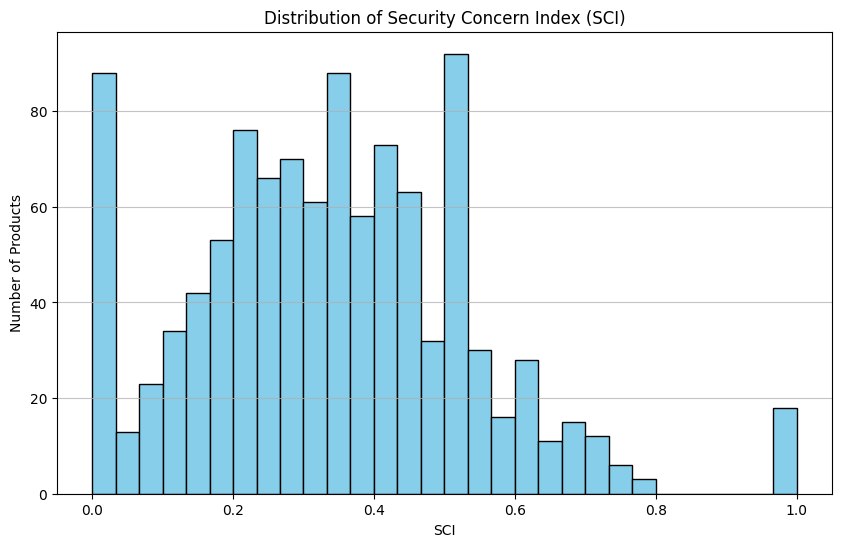

In [157]:
# visualize the distribution of SCI
plt.figure(figsize=(10, 6))
plt.hist(product_data['SCI'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Security Concern Index (SCI)')
plt.xlabel('SCI')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.75)
plt.show()

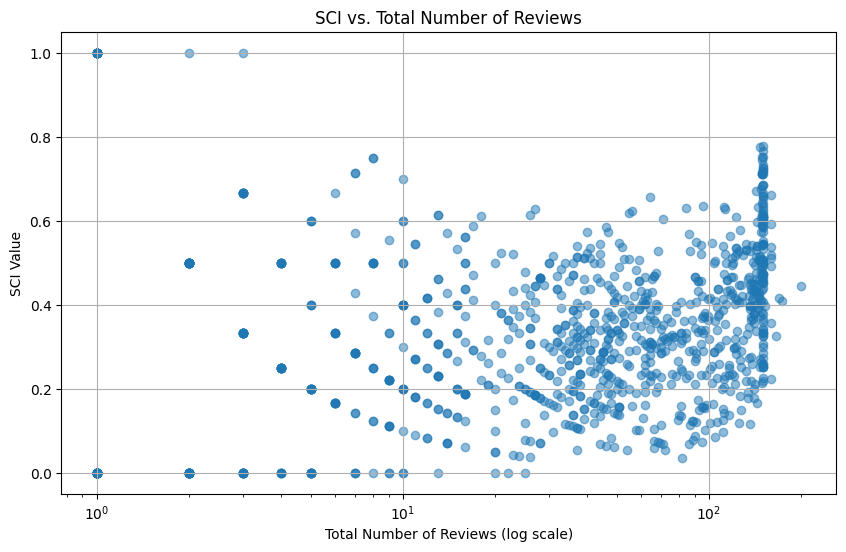

In [158]:
# identify how many reviews should be there to have a reliable SCI
plt.figure(figsize=(10, 6))
plt.scatter(product_data['total_reviews_count'], product_data['SCI'], alpha=0.5)
plt.xscale('log')
plt.title('SCI vs. Total Number of Reviews')
plt.xlabel('Total Number of Reviews (log scale)')
plt.ylabel('SCI Value')
plt.grid(True)
plt.show()

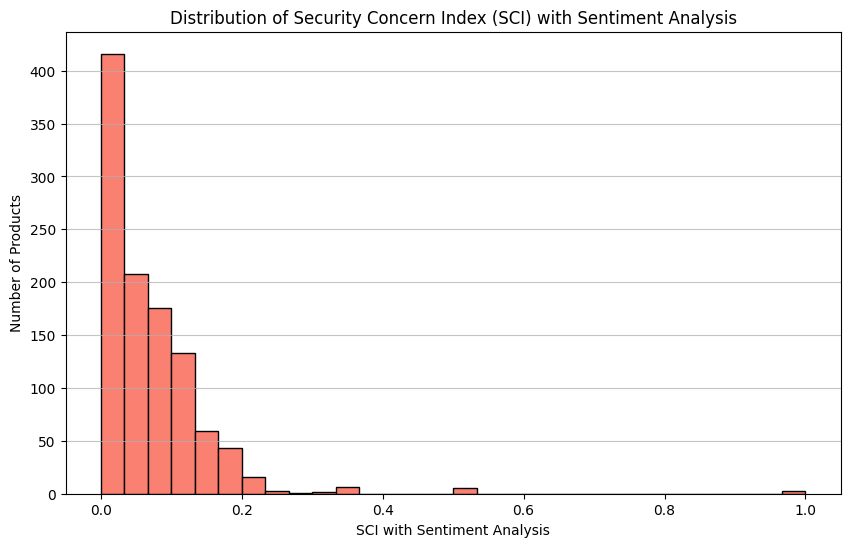

In [159]:
# visualize the distribution of SCI_sentiment
plt.figure(figsize=(10, 6))
plt.hist(product_data['SCI_sentiment'], bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of Security Concern Index (SCI) with Sentiment Analysis')
plt.xlabel('SCI with Sentiment Analysis')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.75)
plt.show()

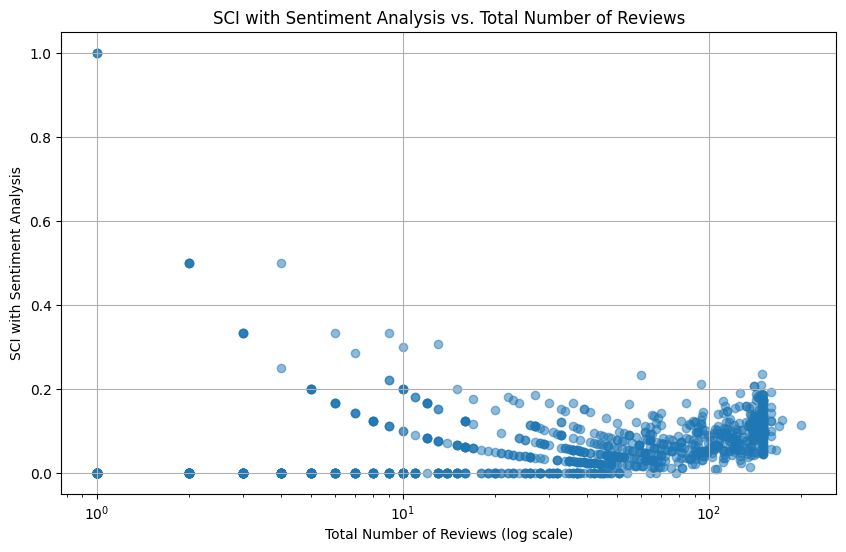

In [160]:
# identify how many reviews should be there to have a reliable SCI
plt.figure(figsize=(10, 6))
plt.scatter(product_data['total_reviews_count'], product_data['SCI_sentiment'], alpha=0.5)
plt.xscale('log')
plt.title('SCI with Sentiment Analysis vs. Total Number of Reviews')
plt.xlabel('Total Number of Reviews (log scale)')
plt.ylabel('SCI with Sentiment Analysis')
plt.grid(True)
plt.show()


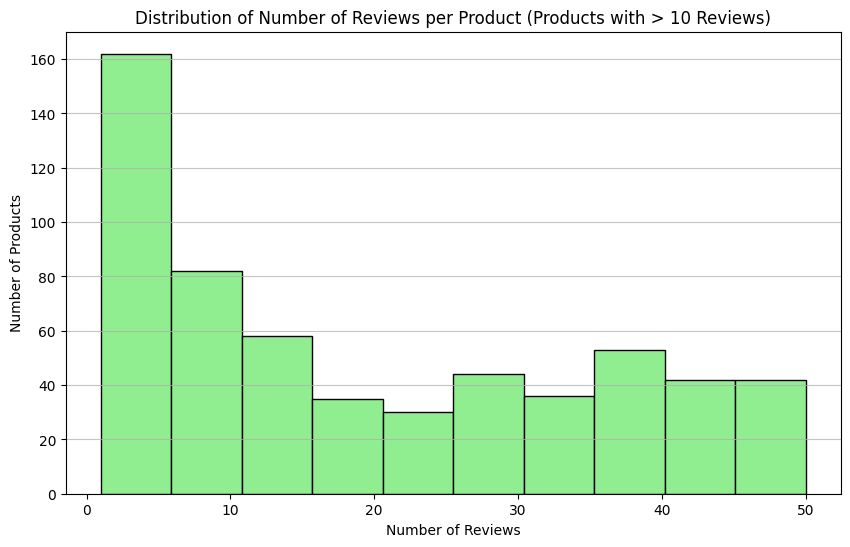

In [161]:
# plot histogram of number of reviews per product with > 10 reviews
plt.figure(figsize=(10, 6))
plt.hist(product_data['total_reviews_count'], bins=10, color='lightgreen', edgecolor='black', range=(1, 50))
plt.title('Distribution of Number of Reviews per Product (Products with > 10 Reviews)')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [162]:
product_data['WebCountry'].unique()

array(['Australia', 'Canada', 'India', 'Singapore', 'UK', 'USA'],
      dtype=object)

#### Filter products > 10 reviews

In [163]:
# filter to products with more than 10 reviews
reliable_product_data = product_data[product_data['total_reviews_count'] > 10]
reliable_product_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 4 to 1347
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Column1                           827 non-null    int64  
 1   Index                             827 non-null    object 
 2   WebCountry                        827 non-null    object 
 3   Link                              827 non-null    object 
 4   Device Type                       827 non-null    object 
 5   Product Title                     827 non-null    object 
 6   Price                             397 non-null    float64
 7   Currency                          397 non-null    float64
 8   Description                       825 non-null    object 
 9   Average Rating                    827 non-null    float64
 10  Total Reviews                     827 non-null    float64
 11  Percent 5 star                    824 non-null    float64
 12  Percent 4 st

In [164]:
reliable_product_data['WebCountry'].unique()

array(['Australia', 'Canada', 'India', 'Singapore', 'UK', 'USA'],
      dtype=object)

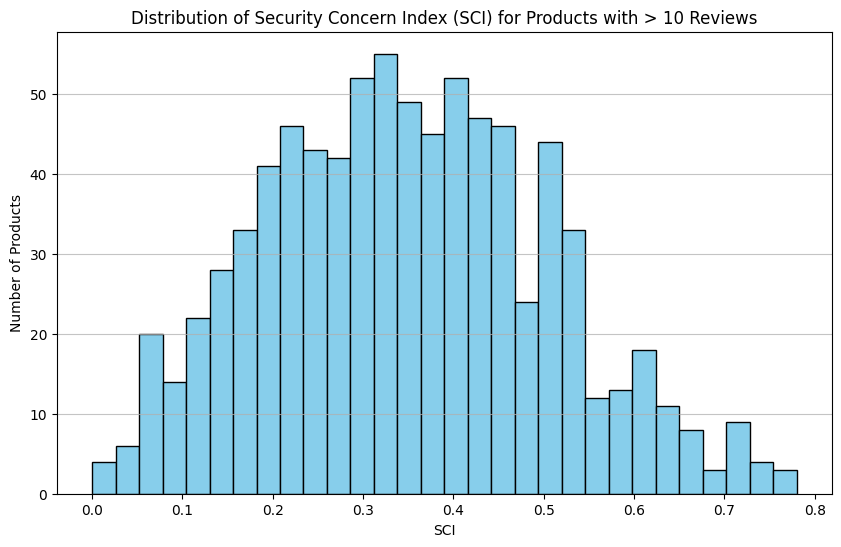

In [165]:
# visualize the distribution of SCI for products with more than 10 reviews
plt.figure(figsize=(10, 6))
plt.hist(reliable_product_data['SCI'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Security Concern Index (SCI) for Products with > 10 Reviews')
plt.xlabel('SCI')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.75)
plt.show()

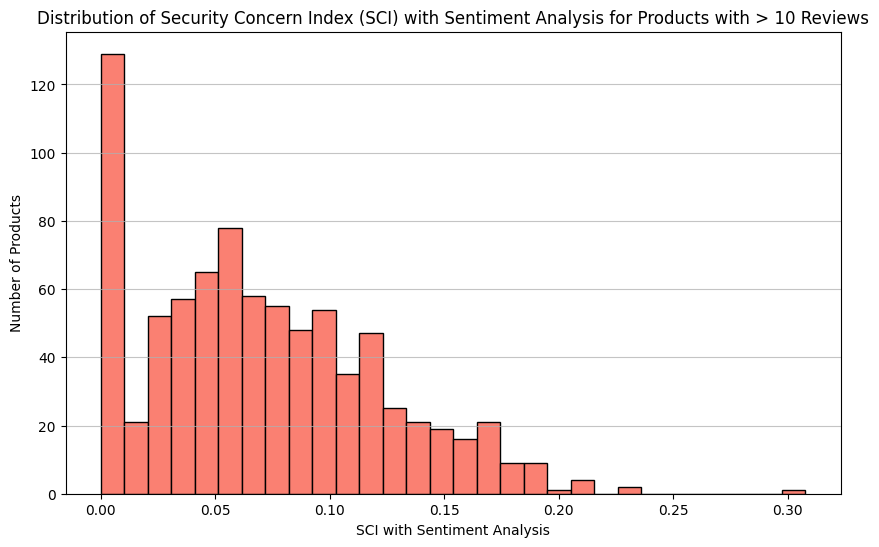

In [166]:
# visualize the distribution of SCI_sentiment for products with more than 10 reviews
plt.figure(figsize=(10, 6))
plt.hist(reliable_product_data['SCI_sentiment'], bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of Security Concern Index (SCI) with Sentiment Analysis for Products with > 10 Reviews')
plt.xlabel('SCI with Sentiment Analysis')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.75)
plt.show()

## SQ 1 - Product Security Quality: 

Do the products with higher SCI (meaning more security and privacy issues) have low star-rating and lower price compared to the devices with low SCI?

## SCI vs Rating

In [167]:
# find the correlation between higher SCI and lower star rating and price
# correlation between SCI and star rating
# non linear and non normal distribution, so we will use Spearman correlation
# but check both just to be safe
correlation_sci_rating_p = reliable_product_data['SCI'].corr(reliable_product_data['Average Rating'],method='pearson')
correlation_sci_rating_s = reliable_product_data['SCI'].corr(reliable_product_data['Average Rating'],method='spearman')
correlation_sci_sentiment_rating_p = reliable_product_data['SCI_sentiment'].corr(reliable_product_data['Average Rating'],method='pearson')
correlation_sci_sentiment_rating_s = reliable_product_data['SCI_sentiment'].corr(reliable_product_data['Average Rating'],method='spearman')
print(f'Correlation between SCI and Star Rating (Pearson): {correlation_sci_rating_p}')
print(f'Correlation between SCI and Star Rating (Spearman): {correlation_sci_rating_s}')
print(f'Correlation between SCI with Sentiment Analysis and Star Rating (Pearson): {correlation_sci_sentiment_rating_p}')
print(f'Correlation between SCI with Sentiment Analysis and Star Rating (Spearman): {correlation_sci_sentiment_rating_s}')

Correlation between SCI and Star Rating (Pearson): 0.2520729873572288
Correlation between SCI and Star Rating (Spearman): 0.27514895899739983
Correlation between SCI with Sentiment Analysis and Star Rating (Pearson): -0.15601031148148695
Correlation between SCI with Sentiment Analysis and Star Rating (Spearman): -0.12278127156160852


Spearman seems to be preferable due to the non-normally distributed SCI_sentiment. Practically both represent minor correlation between SCI and star rating, however SCI correlates positively while SCI with sentiment correlates negatively.

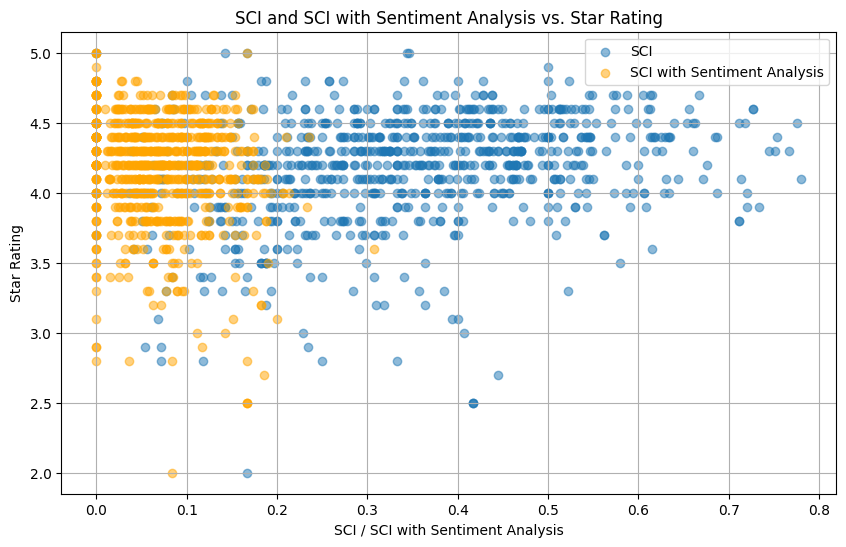

In [168]:
# visualize the correlation between SCI and SCI with sentiment against star rating
plt.figure(figsize=(10, 6))
plt.scatter(reliable_product_data['SCI'], reliable_product_data['Average Rating'], alpha=0.5, label='SCI')
plt.scatter(reliable_product_data['SCI_sentiment'], reliable_product_data['Average Rating'], alpha=0.5, label='SCI with Sentiment Analysis', color='orange')
plt.title('SCI and SCI with Sentiment Analysis vs. Star Rating')
plt.xlabel('SCI / SCI with Sentiment Analysis')
plt.ylabel('Star Rating')
plt.legend()
plt.grid(True)
plt.show()

In [169]:
# run hypothesis test to see if the correlation is significantly different from 0
from scipy.stats import spearmanr
corr_sci, p_value_sci = spearmanr(reliable_product_data['SCI'], reliable_product_data['Average Rating'])
corr_sci_sentiment, p_value_sci_sentiment = spearmanr(reliable_product_data['SCI_sentiment'], reliable_product_data['Average Rating'])
print(f'Spearman Correlation SCI: {corr_sci}, p-value: {p_value_sci}')
print(f'Spearman Correlation SCI with Sentiment: {corr_sci_sentiment}, p-value: {p_value_sci_sentiment}')

Spearman Correlation SCI: 0.27514895899739983, p-value: 7.840049339839301e-16
Spearman Correlation SCI with Sentiment: -0.12278127156160852, p-value: 0.00040171715848764635


Both low p-values mean that the correlation is statistically significant.

#### Group Level Analysis

In [170]:
# bucket the SCI values into low, medium, high based on 33rd and 66th percentiles
low_threshold = reliable_product_data['SCI'].quantile(0.33)
high_threshold = reliable_product_data['SCI'].quantile(0.66)
def bucket_sci(sci):
    if sci <= low_threshold:
        return 'Low'
    elif sci <= high_threshold:
        return 'Medium'
    else:
        return 'High'

reliable_product_data['SCI_Bucket'] = reliable_product_data['SCI'].apply(bucket_sci)


/var/folders/fp/6jm50g552nn8h4gqscvhjd080000gn/T/ipykernel_11493/4258519971.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable_product_data['SCI_Bucket'] = reliable_product_data['SCI'].apply(bucket_sci)


In [171]:
# bucket the SCI_sentiment values based on 25th, 50th, and 75th percentiles
low_threshold_sentiment = reliable_product_data['SCI_sentiment'].quantile(0.25)
medium_threshold_sentiment = reliable_product_data['SCI_sentiment'].quantile(0.50)
high_threshold_sentiment = reliable_product_data['SCI_sentiment'].quantile(0.75)
def bucket_sci_sentiment(sci):
    if sci <= low_threshold_sentiment:
        return 'Low'
    elif sci <= medium_threshold_sentiment:
        return 'Medium-Low'
    elif sci <= high_threshold_sentiment:
        return 'Medium-High'
    else:
        return 'High'

reliable_product_data['SCI_Sentiment_Bucket'] = reliable_product_data['SCI_sentiment'].apply(bucket_sci_sentiment)

/var/folders/fp/6jm50g552nn8h4gqscvhjd080000gn/T/ipykernel_11493/75293482.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable_product_data['SCI_Sentiment_Bucket'] = reliable_product_data['SCI_sentiment'].apply(bucket_sci_sentiment)


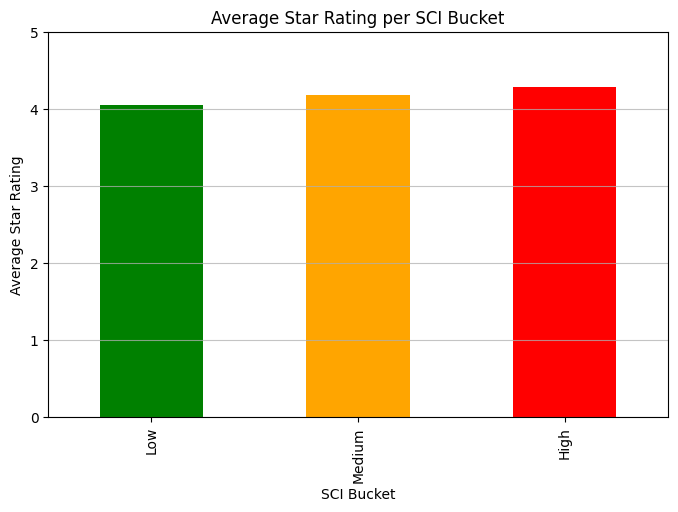

In [172]:
# visualize the average star rating per SCI bucket
sci_bucket_rating = reliable_product_data.groupby('SCI_Bucket')['Average Rating'].mean().reindex(['Low', 'Medium', 'High'])
plt.figure(figsize=(8, 5))
sci_bucket_rating.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Average Star Rating per SCI Bucket')
plt.xlabel('SCI Bucket')
plt.ylabel('Average Star Rating')
plt.ylim(0, 5)
plt.grid(axis='y', alpha=0.75)
plt.show()

The higher SCI bucket, the higher the average star rating.

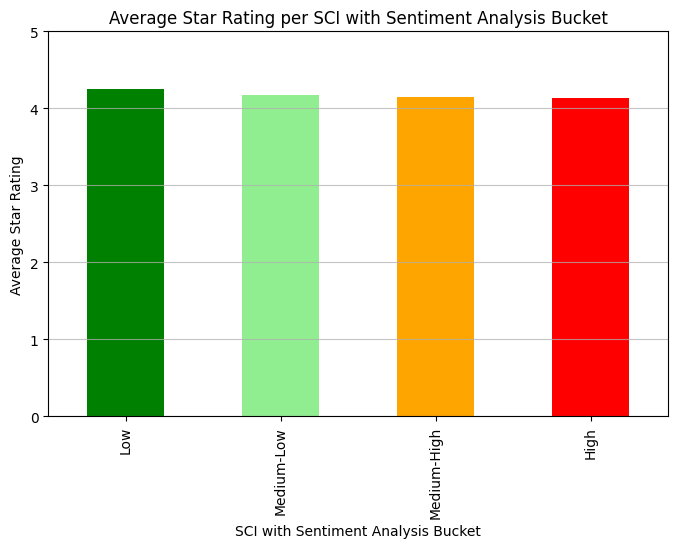

In [173]:
# visualize the average star rating per SCI_sentiment bucket
sci_sentiment_bucket_rating = reliable_product_data.groupby('SCI_Sentiment_Bucket')['Average Rating'].mean().reindex(['Low', 'Medium-Low', 'Medium-High', 'High'])
plt.figure(figsize=(8, 5))
sci_sentiment_bucket_rating.plot(kind='bar', color=['green', 'lightgreen', 'orange', 'red'])
plt.title('Average Star Rating per SCI with Sentiment Analysis Bucket')
plt.xlabel('SCI with Sentiment Analysis Bucket')
plt.ylabel('Average Star Rating')
plt.ylim(0, 5)
plt.grid(axis='y', alpha=0.75)
plt.show()

The higher the SCI with sentiment bucket, the lower the average star rating.

##### Analyse Differences of the Groups

In [174]:
# do ANOVA test to see if the average star ratings are significantly different across SCI and SCI Sentiment buckets
from scipy.stats import f_oneway
low_sci = reliable_product_data[reliable_product_data['SCI_Bucket'] == 'Low']['Average Rating']
medium_sci = reliable_product_data[reliable_product_data['SCI_Bucket'] == 'Medium']['Average Rating']
high_sci = reliable_product_data[reliable_product_data['SCI_Bucket'] == 'High']['Average Rating']
anova_sci = f_oneway(low_sci, medium_sci, high_sci)
print(f'ANOVA SCI: F-statistic={anova_sci.statistic}, p-value={anova_sci.pvalue}')
low_sci_sentiment = reliable_product_data[reliable_product_data['SCI_Sentiment_Bucket'] == 'Low']['Average Rating']
medium_low_sci_sentiment = reliable_product_data[reliable_product_data['SCI_Sentiment_Bucket'] == 'Medium-Low']['Average Rating']
medium_high_sci_sentiment = reliable_product_data[reliable_product_data['SCI_Sentiment_Bucket'] == 'Medium-High']['Average Rating']
high_sci_sentiment = reliable_product_data[reliable_product_data['SCI_Sentiment_Bucket'] == 'High']['Average Rating']
anova_sci_sentiment = f_oneway(low_sci_sentiment, medium_low_sci_sentiment, medium_high_sci_sentiment, high_sci_sentiment)
print(f'ANOVA SCI with Sentiment: F-statistic={anova_sci_sentiment.statistic}, p-value={anova_sci_sentiment.pvalue}')

ANOVA SCI: F-statistic=27.82701281457828, p-value=2.02074108848673e-12
ANOVA SCI with Sentiment: F-statistic=3.9722372774107315, p-value=0.007957605764372684


ANOVA is better used for non-parametrics and normally distributed data. It shows that results are statistically significant and larger group separation for SCI buckets compared to SCI with sentiments.

In [175]:
# do kruskal wallis test to see if the average star ratings are significantly different across SCI and SCI Sentiment buckets
from scipy.stats import kruskal
kruskal_sci = kruskal(low_sci, medium_sci, high_sci)
print(f'Kruskal-Wallis SCI: H-statistic={kruskal_sci.statistic}, p-value={kruskal_sci.pvalue}')
kruskal_sci_sentiment = kruskal(low_sci_sentiment, medium_low_sci_sentiment, medium_high_sci_sentiment, high_sci_sentiment)
print(f'Kruskal-Wallis SCI with Sentiment: H-statistic={kruskal_sci_sentiment.statistic}, p-value={kruskal_sci_sentiment.pvalue}')

# kruskal wallis is more appropriate here given the non normal distribution and different sample sizes

Kruskal-Wallis SCI: H-statistic=60.99845385759748, p-value=5.6800746378762665e-14
Kruskal-Wallis SCI with Sentiment: H-statistic=11.6553203543347, p-value=0.008662170620102017


Kruskal-Wallis confirms ANOVA, and more robust for more non-conforming data.

#### **SCI (without sentiment) vs Star Rating**
- **Higher SCI values are associated with lower star ratings.**
  - The correlation analysis (Spearman and Pearson) found a statistically significant but weak association.
  - Group-wise comparisons (ANOVA and Kruskal-Wallis) showed that star ratings differ meaningfully between products categorized as low, medium, and high SCI.
- **SCI reflects the frequency of security/privacy mentions in reviews.**
  - High SCI does not necessarily mean dissatisfaction: many mentions could be neutral or positive.
  - This is why highly rated products can still have moderate to high SCI.


#### **SCI_sentiment vs Star Rating**
SCI_sentiment is not normally distributed which changes how things work in two ways:
- Categorization is done in quartiles instead of 33rd and 66th percentiles.
- Spearman is preferred for correlation and Kruskal-Wallis is preferred for categorical correlation.
- **Higher SCI_sentiment (more negative security/privacy reviews) is associated with lower star ratings.**
  - The negative correlation that is found (small but significant) is in line with expectations: more negative security issues signal less user satisfaction.
  - ANOVA also confirms that average ratings differ statistically between groups split by SCI_sentiment (quartiles or percentiles).
- **SCI_sentiment is a sharper tool for actual dissatisfaction.**
  - Products with high SCI_sentiment are rare, but they are far more likely to have lower star ratings.
  - This metric helps distinguish between general discussion and meaningful user concern.


#### **Statistical Significance**
- Both SCI and SCI_sentiment show **statistically significant differences** in average ratings across their groups.
- Effect sizes (F-statistic, Kruskal-Wallis H) are higher for SCI than SCI_sentiment, but SCI_sentiment aligns more closely with negative perception.


#### **Best Practice Insight**
- **SCI is useful for identifying discussion frequency,** but may overstate dissatisfaction if not filtered by sentiment.
- **SCI_sentiment should be prioritized** for identifying products genuinely at risk due to negative security/privacy perceptions.
- Results support filtering products by review count, bucketing SCI/Sentiment by percentiles, and using non-parametric methods for robust analysis.


## SCI vs Price

In [100]:
# check data
reliable_product_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 4 to 1347
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Column1                           827 non-null    int64  
 1   Index                             827 non-null    object 
 2   WebCountry                        827 non-null    object 
 3   Link                              827 non-null    object 
 4   Device Type                       827 non-null    object 
 5   Product Title                     827 non-null    object 
 6   Price                             397 non-null    float64
 7   Currency                          397 non-null    float64
 8   Description                       825 non-null    object 
 9   Average Rating                    827 non-null    float64
 10  Total Reviews                     827 non-null    float64
 11  Percent 5 star                    824 non-null    float64
 12  Percent 4 st

In [177]:
reliable_product_data['WebCountry'].unique()

array(['Australia', 'Canada', 'India', 'Singapore', 'UK', 'USA'],
      dtype=object)

In [179]:
# drop empty rows in Price
reliable_product_data_with_price = reliable_product_data[reliable_product_data['Price'].notna()]
reliable_product_data_with_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397 entries, 4 to 1346
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Column1                           397 non-null    int64  
 1   Index                             397 non-null    object 
 2   WebCountry                        397 non-null    object 
 3   Link                              397 non-null    object 
 4   Device Type                       397 non-null    object 
 5   Product Title                     397 non-null    object 
 6   Price                             397 non-null    float64
 7   Currency                          397 non-null    float64
 8   Description                       397 non-null    object 
 9   Average Rating                    397 non-null    float64
 10  Total Reviews                     397 non-null    float64
 11  Percent 5 star                    394 non-null    float64
 12  Percent 4 st

In [180]:
reliable_product_data_with_price['WebCountry'].unique()

array(['Australia', 'Canada', 'USA'], dtype=object)

In [181]:
# correlation between SCI and price
correlation_sci_price_p = reliable_product_data_with_price['SCI'].corr(reliable_product_data_with_price['Price'],method='pearson')
correlation_sci_price_s = reliable_product_data_with_price['SCI'].corr(reliable_product_data_with_price['Price'],method='spearman')
correlation_sci_sentiment_price_p = reliable_product_data_with_price['SCI_sentiment'].corr(reliable_product_data_with_price['Price'],method='pearson')
correlation_sci_sentiment_price_s = reliable_product_data_with_price['SCI_sentiment'].corr(reliable_product_data_with_price['Price'],method='spearman')
print(f'Correlation between SCI and Price (Pearson): {correlation_sci_price_p}')
print(f'Correlation between SCI and Price (Spearman): {correlation_sci_price_s}')
print(f'Correlation between SCI with Sentiment Analysis and Price (Pearson): {correlation_sci_sentiment_price_p}')
print(f'Correlation between SCI with Sentiment Analysis and Price (Spearman): {correlation_sci_sentiment_price_s}')

Correlation between SCI and Price (Pearson): 0.0546959344139914
Correlation between SCI and Price (Spearman): 0.12913988665342907
Correlation between SCI with Sentiment Analysis and Price (Pearson): -0.11972159477046129
Correlation between SCI with Sentiment Analysis and Price (Spearman): -0.012361224455418108


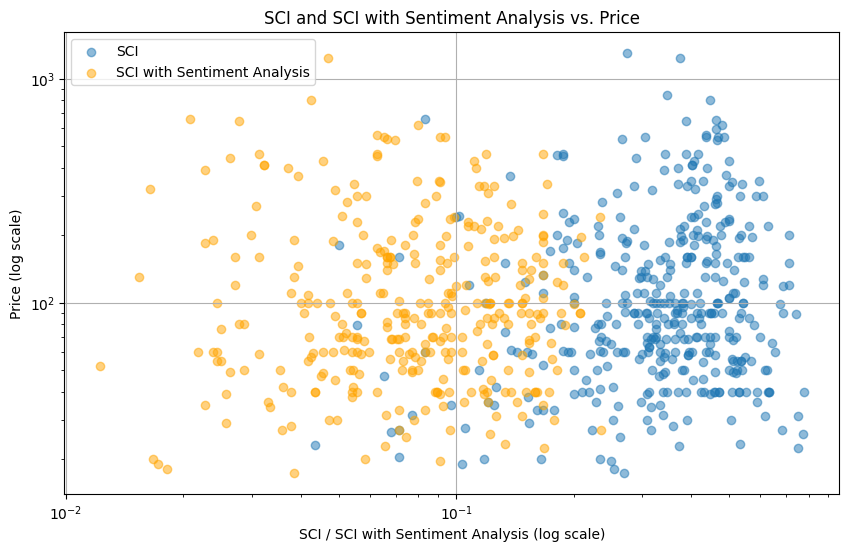

In [182]:
# visualize the correlation between SCI and SCI with sentiment against price
plt.figure(figsize=(10, 6))
plt.scatter(reliable_product_data_with_price['SCI'], reliable_product_data_with_price['Price'], alpha=0.5, label='SCI')
plt.scatter(reliable_product_data_with_price['SCI_sentiment'], reliable_product_data_with_price['Price'], alpha=0.5, label='SCI with Sentiment Analysis', color='orange')
plt.xscale('log')
plt.yscale('log')
plt.title('SCI and SCI with Sentiment Analysis vs. Price')
plt.xlabel('SCI / SCI with Sentiment Analysis (log scale)')
plt.ylabel('Price (log scale)')
plt.legend()
plt.grid(True)
plt.show()


Very low correlation, trying to view segmentations in product types

In [183]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# Initialize a list to collect results
results = []

# Loop over each unique Device Type
for device_type in reliable_product_data_with_price['Device Type'].unique():
    subset = reliable_product_data_with_price[reliable_product_data_with_price['Device Type'] == device_type]

    # Drop NA values for columns needed for correlation tests
    subset = subset.dropna(subset=['SCI', 'SCI_sentiment', 'Price'])
    
    if len(subset) < 5:
        # Skip small sample sizes for reliability
        continue
    
    # Pearson correlations
    pearson_sci_corr, pearson_sci_p = pearsonr(subset['SCI'], subset['Price'])
    pearson_sent_corr, pearson_sent_p = pearsonr(subset['SCI_sentiment'], subset['Price'])
    
    # Spearman correlations
    spearman_sci_corr, spearman_sci_p = spearmanr(subset['SCI'], subset['Price'])
    spearman_sent_corr, spearman_sent_p = spearmanr(subset['SCI_sentiment'], subset['Price'])
    
    results.append({
        'Device Type': device_type,
        'Pearson SCI vs Price': pearson_sci_corr,
        'Pearson SCI p-value': pearson_sci_p,
        'Spearman SCI vs Price': spearman_sci_corr,
        'Spearman SCI p-value': spearman_sci_p,
        'Pearson SCI_sentiment vs Price': pearson_sent_corr,
        'Pearson SCI_sentiment p-value': pearson_sent_p,
        'Spearman SCI_sentiment vs Price': spearman_sent_corr,
        'Spearman SCI_sentiment p-value': spearman_sent_p
    })

# Convert results to a DataFrame for easy viewing
correlation_by_device_type = pd.DataFrame(results)

# Display the result
correlation_by_device_type


,Device Type,Pearson SCI vs Price,Pearson SCI p-value,Spearman SCI vs Price,Spearman SCI p-value,Pearson SCI_sentiment vs Price,Pearson SCI_sentiment p-value,Spearman SCI_sentiment vs Price,Spearman SCI_sentiment p-value
0,Surveillance systems,-0.061992,0.325081,-0.073440,2.435181e-01,-0.193059,0.001996,-0.150595,0.016307
1,Router,0.265763,0.002969,0.450230,1.742485e-07,0.023117,0.799654,0.189472,0.035822
2,Set top box,0.305377,0.310289,0.145805,6.345803e-01,0.020038,0.948194,-0.089532,0.771152
3,Smart home hub,0.584390,0.168243,0.846881,1.619713e-02,0.158113,0.734922,0.642857,0.119392


The one that is most closely related to our hypothesis is for surveillance systems. For router, while it is statistically significant, it shows positive correlation between SCI and price. Other device types, when analysed with SCI with sentiment analysis, are statistically insignificant with the prices. This insignificance might be due to sample sizes or limited variability.

On the other hand, Routers and Smart home hubs have statistical significance with Spearman when analysed with SCI without sentiment analysis, counterintuitively, has a positive relationship with price.

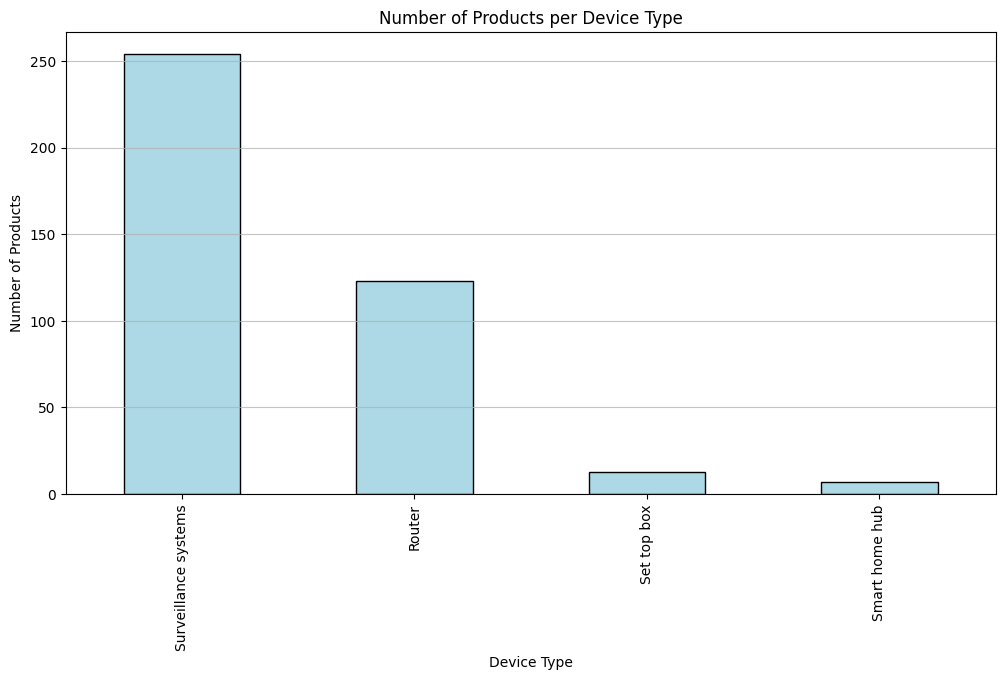

In [184]:
# visualize how many products are in each device type
device_type_counts = reliable_product_data_with_price['Device Type'].value_counts()
plt.figure(figsize=(12, 6))
device_type_counts.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Number of Products per Device Type')
plt.xlabel('Device Type')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [185]:
reliable_product_data_with_price.columns

Index(['Column1', 'Index', 'WebCountry', 'Link', 'Device Type',
       'Product Title', 'Price', 'Currency', 'Description', 'Average Rating',
       'Total Reviews', 'Percent 5 star', 'Percent 4 star', 'Percent 3 star',
       'Percent 2 star', 'Percent 1 star', 'total_reviews_count',
       'security_reviews_count', 'sentiment_security_reviews_count', 'SCI',
       'SCI_sentiment', 'SCI_Bucket', 'SCI_Sentiment_Bucket'],
      dtype='object')

In [188]:
reliable_product_data_with_price['WebCountry'].unique()

array(['Australia', 'Canada', 'USA'], dtype=object)

In [186]:
reliable_product_data_with_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397 entries, 4 to 1346
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Column1                           397 non-null    int64  
 1   Index                             397 non-null    object 
 2   WebCountry                        397 non-null    object 
 3   Link                              397 non-null    object 
 4   Device Type                       397 non-null    object 
 5   Product Title                     397 non-null    object 
 6   Price                             397 non-null    float64
 7   Currency                          397 non-null    float64
 8   Description                       397 non-null    object 
 9   Average Rating                    397 non-null    float64
 10  Total Reviews                     397 non-null    float64
 11  Percent 5 star                    394 non-null    float64
 12  Percent 4 st

In [187]:
import statsmodels.api as sm

# Make a copy to avoid SettingWithCopyWarning
df = reliable_product_data_with_price.copy()

# --- Feature Engineering ---
# Convert categorical variables to dummy/indicator variables
# df = pd.get_dummies(df, columns=['Device Type', 'WebCountry', 'SCI_Bucket', 'SCI_Sentiment_Bucket'], drop_first=True)
df = pd.get_dummies(df, columns=['Device Type', 'WebCountry', 'SCI_Bucket', 'SCI_Sentiment_Bucket'], drop_first=True, dtype=int)

# Select predictors (you can customize this list)
predictors = [
    'Average Rating', 'Total Reviews', 'Percent 5 star', 'Percent 4 star',
    'Percent 3 star', 'Percent 2 star', 'Percent 1 star', 'total_reviews_count',
    'security_reviews_count', 'sentiment_security_reviews_count', 'SCI', 'SCI_sentiment'
] + [col for col in df.columns if col.startswith('Device Type_') or col.startswith('WebCountry_')]

# Drop rows with missing values for predictors or price
df_model = df.dropna(subset=predictors + ['Price'])

# Add intercept
X = sm.add_constant(df_model[predictors])
y = df_model['Price']

# Build OLS regression model
model = sm.OLS(y, X).fit()

# View results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     3.788
Date:                Fri, 10 Oct 2025   Prob (F-statistic):           1.10e-06
Time:                        16:41:13   Log-Likelihood:                -2088.7
No. Observations:                 327   AIC:                             4213.
Df Residuals:                     309   BIC:                             4282.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

Statistically insignificant

Checking multicollinearity

In [190]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Make a copy to avoid SettingWithCopyWarning
df = reliable_product_data_with_price.copy()

# Convert categorical variables to dummy/indicator variables with int dtype
df = pd.get_dummies(df, columns=['Device Type', 'WebCountry', 'SCI_Bucket', 'SCI_Sentiment_Bucket'], drop_first=True, dtype=int)

# Select predictors (customize as needed)
predictors = [
    'Average Rating', 'Total Reviews', 'Percent 5 star', 'Percent 4 star',
    'Percent 3 star', 'Percent 2 star', 'Percent 1 star', 'total_reviews_count',
    'security_reviews_count', 'sentiment_security_reviews_count', 'SCI', 'SCI_sentiment'
] + [col for col in df.columns if col.startswith('Device Type_') or col.startswith('WebCountry_')]

# Drop rows with missing data in predictors or Price
df_model = df.dropna(subset=predictors + ['Price'])

# Prepare design matrix with constant added for intercept
X = sm.add_constant(df_model[predictors])

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


                             feature           VIF
0                              const  40793.359919
1                     Average Rating    165.578427
2                      Total Reviews      1.290981
3                     Percent 5 star    441.736022
4                     Percent 4 star     43.833190
5                     Percent 3 star     37.164647
6                     Percent 2 star     21.591048
7                     Percent 1 star    149.553869
8                total_reviews_count     10.667873
9             security_reviews_count     31.697039
10  sentiment_security_reviews_count     19.427017
11                               SCI      7.656085
12                     SCI_sentiment      6.166379
13           Device Type_Set top box      1.174468
14        Device Type_Smart home hub      1.128996
15  Device Type_Surveillance systems      1.341716
16                 WebCountry_Canada     27.558718
17                    WebCountry_USA     28.022020


Very likely multicollinear

In [199]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load your dataset with price and SCI variables already prepared
df = reliable_product_data_with_price.copy()

# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix for numeric columns
corr_matrix = df[numeric_cols].corr()

# Correlations of each variable with Price, SCI, and SCI_sentiment
price_corr = corr_matrix['Price'].sort_values(ascending=False)
sci_corr = corr_matrix['SCI'].sort_values(ascending=False)
sci_sentiment_corr = corr_matrix['SCI_sentiment'].sort_values(ascending=False)

print("Correlations with Price:")
print(price_corr)
print("\nCorrelations with SCI:")
print(sci_corr)
print("\nCorrelations with SCI_sentiment:")
print(sci_sentiment_corr)

# Choose variables that have:
# (1) absolute correlation with Price > 0.1 (weak threshold but adjustable)
# (2) absolute correlation with SCI and SCI_sentiment < 0.7 (to reduce collinearity)
selected_vars = []
for col in numeric_cols:
    if col == 'Price' or col == 'Column1' or col == 'Currency':
        continue
    if (abs(price_corr[col]) > 0.01) and (abs(sci_corr[col]) < 0.7) and (abs(sci_sentiment_corr[col]) < 0.7):
        selected_vars.append(col)

print("\nSelected variables for VIF and modeling:")
print(selected_vars)

# Prepare data for VIF calculation
df_model = df.dropna(subset=selected_vars + ['Price']).copy()
X = sm.add_constant(df_model[selected_vars])

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVariance Inflation Factor (VIF):")
print(vif_data)

# Optional: drop variables with high VIF and rebuild model after feature selection


Correlations with Price:
Price                               1.000000
Currency                            1.000000
Percent 5 star                      0.210328
Average Rating                      0.174109
Percent 4 star                      0.062292
SCI                                 0.054696
Total Reviews                      -0.111454
SCI_sentiment                      -0.119722
Percent 1 star                     -0.123115
Column1                            -0.125180
Percent 3 star                     -0.137726
security_reviews_count             -0.137990
Percent 2 star                     -0.138287
sentiment_security_reviews_count   -0.165361
total_reviews_count                -0.192593
Name: Price, dtype: float64

Correlations with SCI:
SCI                                 1.000000
security_reviews_count              0.724627
sentiment_security_reviews_count    0.577094
SCI_sentiment                       0.541424
total_reviews_count                 0.440992
Total Reviews          

Basically the SCI does not matter to pricing

## SQ 2 - Regulatory Relevance:

How does SCI vary across countries? Can these differences help the regulators to identify market needs and provide more security to the customers?

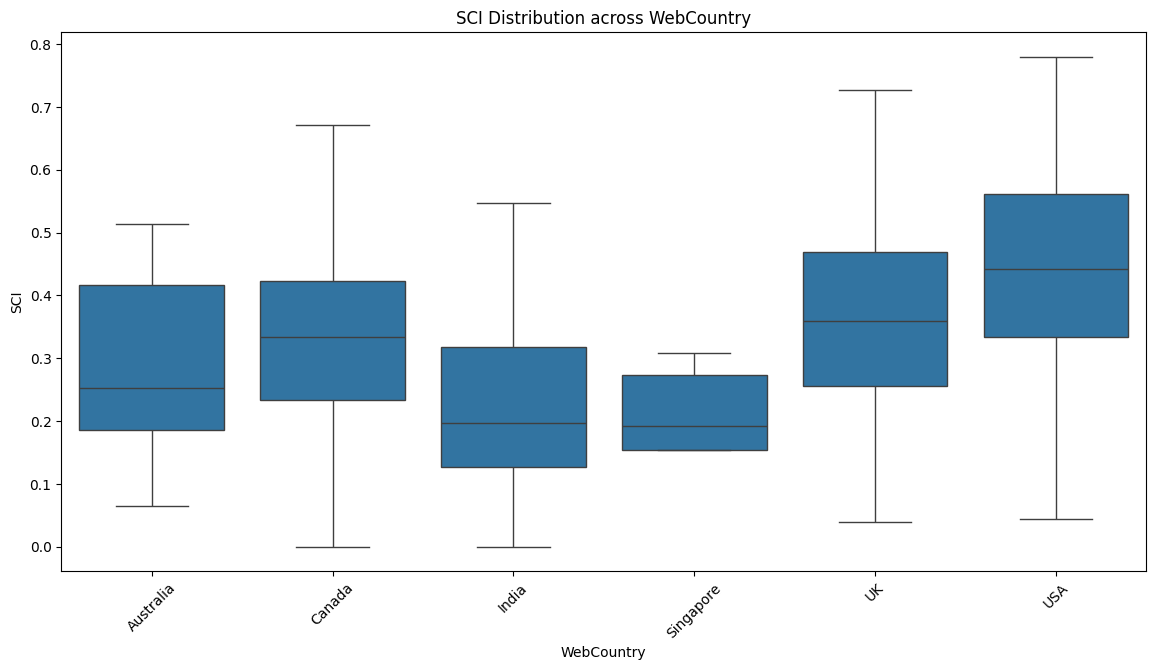

In [194]:
# check SCI and SCI_sentiment variance across WebCountry
import seaborn as sns
plt.figure(figsize=(14, 7))
sns.boxplot(x='WebCountry', y='SCI', data=reliable_product_data)
plt.title('SCI Distribution across WebCountry')
plt.xlabel('WebCountry')
plt.ylabel('SCI')
plt.xticks(rotation=45)
plt.show()

## SQ 3 - Manufacturer and Product Type Differences:

### Do certain manufacturers or product categories systematically show higher SCI values, and what does this reveal about their incentives to invest in security?

In [ ]:
### # Da